In [1]:
import os 

# set directory to parent directory
os.chdir("/cluster/work/vogtlab/Group/jogoncalves/treevae")

# print current working directory
print("Current Working Directory:", os.getcwd())


Current Working Directory: /cluster/work/vogtlab/Group/jogoncalves/treevae


In [2]:
from FID.fid_score import calculate_fid, get_precomputed_fid_scores_path, save_fid_stats_as_dict
import gzip
import numpy as np
import os
from PIL import Image
import pickle
import torch
import yaml
import argparse
import matplotlib.pyplot as plt
from pathlib import Path
from utils.data_utils import get_data, get_gen
from utils.utils import reset_random_seeds, prepare_config
from models.losses import loss_reconstruction_binary, loss_reconstruction_mse
from concurrent.futures import ThreadPoolExecutor, as_completed

In [3]:
path = 'models/experiments/'

dataset = 'cifar10/'
ex_name = '20240613-111829_7bc09'

checkpoint_path = path+dataset+ex_name
with open(checkpoint_path + "/config.yaml", 'r') as stream:
    configs = yaml.load(stream,Loader=yaml.Loader)
print(configs)

from utils.data_utils import get_data, get_gen

# load data
trainset, trainset_eval, testset = get_data(configs)
gen_train = get_gen(trainset, configs, validation=False, shuffle=False)
gen_train_eval = get_gen(trainset_eval, configs, validation=True, shuffle=False)
gen_test = get_gen(testset, configs, validation=True, shuffle=False)
gen_train_eval_iter = iter(gen_train_eval)
gen_test_iter = iter(gen_test)
y_train = trainset_eval.dataset.targets.clone().detach()[trainset_eval.indices].numpy()
y_test = testset.dataset.targets.clone().detach()[testset.indices].numpy()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

{'data': {'data_name': 'cifar10', 'num_clusters_data': 10}, 'ddpm': {'data': {'data_name': 'cifar10', 'ddpm_latent_path': '', 'image_size': 32, 'inp_channels': 3, 'norm': True, 'num_clusters_data': 10}, 'evaluation': {'chkpt_path': '/cluster/work/vogtlab/Group/jogoncalves/results/cifar10/checkpoints/ddpmv2-vae-epoch=934-loss=0.0109.ckpt', 'eval_mode': 'sample_all_leaves', 'guidance_weight': 0.0, 'n_samples': 10000, 'n_steps': 1000, 'resample_strategy': 'truncated', 'sample_from': 'target', 'sample_method': 'ddpm', 'sample_prefix': '', 'save_mode': 'image', 'save_path': '/cluster/work/vogtlab/Group/jogoncalves/results/cifar10/', 'save_vae': True, 'skip_strategy': 'quad', 'temp': 1.0, 'type': 'form1', 'variance': 'fixedlarge', 'z_cond': False, 'z_dim': 1}, 'globals': {'seed': 42}, 'model': {'attn_resolutions': '16,', 'beta1': 0.0001, 'beta2': 0.02, 'dim': 64, 'dim_mults': '1,2,2,2', 'dropout': 0.3, 'n_heads': 8, 'n_residual': 2, 'n_timesteps': 1000}, 'training': {'batch_size': 256, 'cfd_

In [4]:
print(device)

cuda


In [5]:
def load_image(file_path):
    img = Image.open(file_path)
    return np.array(img)

def load_images_from_path(path):
    images = []
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(load_image, os.path.join(path, filename))
                   for filename in os.listdir(path) if filename.endswith(".png")]
        for future in as_completed(futures):
            images.append(future.result())
    return np.array(images)

In [8]:
ddpm_samples_path = '../results_latent_emb/' + dataset + 'cond_on_recons/' + 'seed_1/ddpm/sample/'
ddpm_reconstructions_path = '../results_latent_emb/' + dataset + 'cond_on_recons/' + 'seed_1/ddpm/recons/'

vae_samples_path = '../results_latent_emb/' + dataset + 'cond_on_recons/' + 'seed_1/vae/sample/'
vae_reconstructions_path = '../results_latent_emb/' + dataset + 'cond_on_recons/' + 'seed_1/vae/recons/'

In [9]:
ddpm_samples = load_images_from_path(ddpm_samples_path)
print("Nb. of ddpm samples: ", len(ddpm_samples), "\n")

ddpm_reconstructions = load_images_from_path(ddpm_reconstructions_path)
print("Nb. of ddpm reconstructions: ", len(ddpm_reconstructions), "\n")

vae_samples = load_images_from_path(vae_samples_path)
print("Nb. of vae samples: ", len(vae_samples), "\n")

vae_reconstructions = load_images_from_path(vae_reconstructions_path)
print("Nb. of vae reconstructions: ", len(vae_reconstructions), "\n")

Nb. of ddpm samples:  10000 

Nb. of ddpm reconstructions:  10000 

Nb. of vae samples:  10000 

Nb. of vae reconstructions:  10000 



In [10]:
# precompute or load fid scores for train and test
data_stats_train = get_precomputed_fid_scores_path(trainset.dataset.data, configs['data']['data_name'],
                                                subset="train", device=device)
data_stats_test = get_precomputed_fid_scores_path(testset.dataset.data, configs['data']['data_name'], subset="test",
                                                device=device)

---

VAE SAMPLES

In [11]:
# precompute FID scores for generated images
stats_generations = save_fid_stats_as_dict(vae_samples, batch_size=256, device=device, dims=2048)
train_FID_generations = calculate_fid([data_stats_train, stats_generations], batch_size=256, device=device, dims=2048)
test_FID_generations = calculate_fid([data_stats_test, stats_generations], batch_size=256, device=device, dims=2048)
print("FID score for generated images compared to train set:", train_FID_generations)
print("FID score for generated images compared to test set:", test_FID_generations)

Saving FID statistics


100%|██████████| 40/40 [00:23<00:00,  1.68it/s]


FID score for generated images compared to train set: 194.93603217593773
FID score for generated images compared to test set: 196.21877022369966


DDPM SAMPLES

In [12]:
# precompute FID scores for generated images
stats_generations = save_fid_stats_as_dict(ddpm_samples, batch_size=256, device=device, dims=2048)
train_FID_generations = calculate_fid([data_stats_train, stats_generations], batch_size=256, device=device, dims=2048)
test_FID_generations = calculate_fid([data_stats_test, stats_generations], batch_size=256, device=device, dims=2048)
print("FID score for generated images compared to train set:", train_FID_generations)
print("FID score for generated images compared to test set:", test_FID_generations)


Saving FID statistics


100%|██████████| 40/40 [00:12<00:00,  3.13it/s]


FID score for generated images compared to train set: 22.12486394490145
FID score for generated images compared to test set: 24.207185536995098


---

VAE RECONSTRUCTIONS

In [13]:
# precompute FID scores for generated images
stats_generations = save_fid_stats_as_dict(vae_reconstructions, batch_size=256, device=device, dims=2048)
train_FID_generations = calculate_fid([data_stats_train, stats_generations], batch_size=256, device=device, dims=2048)
test_FID_generations = calculate_fid([data_stats_test, stats_generations], batch_size=256, device=device, dims=2048)
print("FID score for generated images compared to train set:", train_FID_generations)
print("FID score for generated images compared to test set:", test_FID_generations)

Saving FID statistics


100%|██████████| 40/40 [00:12<00:00,  3.13it/s]


FID score for generated images compared to train set: 177.31792665883415
FID score for generated images compared to test set: 178.60579615116274


DDPM RECONSTRUCTIONS

In [14]:
# precompute FID scores for generated images
stats_generations = save_fid_stats_as_dict(ddpm_reconstructions, batch_size=256, device=device, dims=2048)
train_FID_generations = calculate_fid([data_stats_train, stats_generations], batch_size=256, device=device, dims=2048)
test_FID_generations = calculate_fid([data_stats_test, stats_generations], batch_size=256, device=device, dims=2048)
print("FID score for generated images compared to train set:", train_FID_generations)
print("FID score for generated images compared to test set:", test_FID_generations)

Saving FID statistics


100%|██████████| 40/40 [00:12<00:00,  3.12it/s]


FID score for generated images compared to train set: 14.112600485868313
FID score for generated images compared to test set: 16.047490657873198


---
---

# MNIST

In [ ]:

dataset = 'mnist/'

# use config of some trained mnist model to load data correctly
ex_name = '20240221-150914_9e40a'

checkpoint_path = path+dataset+ex_name
with open(checkpoint_path + "/config.yaml", 'r') as stream:
    configs = yaml.load(stream,Loader=yaml.Loader)

# load data
trainset, trainset_eval, testset = get_data(configs)
gen_train = get_gen(trainset, configs, validation=False, shuffle=False)
gen_train_eval = get_gen(trainset_eval, configs, validation=True, shuffle=False)
gen_test = get_gen(testset, configs, validation=True, shuffle=False)
gen_train_eval_iter = iter(gen_train_eval)
gen_test_iter = iter(gen_test)
y_train = trainset_eval.dataset.targets.clone().detach()[trainset_eval.indices].numpy()
y_test = testset.dataset.targets.clone().detach()[testset.indices].numpy()

# setup device, mps is for M1 or M2 macs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "mps"

# precompute or load fid scores for train and test
data_stats_train = get_precomputed_fid_scores_path(trainset.dataset.data, configs['data']['data_name'],
                                                subset="train", device=device)
data_stats_test = get_precomputed_fid_scores_path(testset.dataset.data, configs['data']['data_name'], subset="test",
                                                device=device)

# paths to the generated images
base_path = '../from_cluster/results/'
seed_list = ["seed_1", "seed_2", "seed_3", "seed_4", "seed_5", "seed_6", "seed_7", "seed_8", "seed_9", "seed_10"]

# lists to store FID scores for each seed
mnist_train_FID_generations_ddpm = []
mnist_test_FID_generations_ddpm = []
mnist_train_FID_reconstructions_ddpm = []
mnist_test_FID_reconstructions_ddpm = []

for i, seed in enumerate(seed_list):
    ddpm_samples_path = base_path + dataset + seed + '/ddpm/sample/'
    ddpm_reconstructions_path = base_path + dataset + seed + '/ddpm/recons/'

    # load all images from the path and create a numpy array
    ddpm_samples = []
    for filename in os.listdir(ddpm_samples_path):
        if filename.endswith(".png"):
            img = Image.open(ddpm_samples_path + filename)
            img = np.array(img)
            ddpm_samples.append(img)
    ddpm_samples = np.array(ddpm_samples)

    ddpm_reconstructions = []
    for filename in os.listdir(ddpm_reconstructions_path):
        if filename.endswith(".png"):
            img = Image.open(ddpm_reconstructions_path + filename)
            img = np.array(img)
            ddpm_reconstructions.append(img)
    ddpm_reconstructions = np.array(ddpm_reconstructions)

    # precompute FID scores for generated and reconstructed images of DDPM

    # DDPM samples
    ddpm_stats_generations = save_fid_stats_as_dict(ddpm_samples, batch_size=256, device=device, dims=2048)
    train_FID_gen_ddpm = calculate_fid([data_stats_train, ddpm_stats_generations], batch_size=256, device=device, dims=2048)
    test_FID_gen_ddpm = calculate_fid([data_stats_test, ddpm_stats_generations], batch_size=256, device=device, dims=2048)
    mnist_train_FID_generations_ddpm.append(train_FID_gen_ddpm)
    mnist_test_FID_generations_ddpm.append(test_FID_gen_ddpm)

    # DDPM reconstructions
    ddpm_stats_reconstructions = save_fid_stats_as_dict(ddpm_reconstructions, batch_size=256, device=device, dims=2048)
    train_FID_recon_ddpm = calculate_fid([data_stats_train, ddpm_stats_reconstructions], batch_size=256, device=device, dims=2048)
    test_FID_recon_ddpm = calculate_fid([data_stats_test, ddpm_stats_reconstructions], batch_size=256, device=device, dims=2048)
    mnist_train_FID_reconstructions_ddpm.append(train_FID_recon_ddpm)
    mnist_test_FID_reconstructions_ddpm.append(test_FID_recon_ddpm)



In [29]:
print("\nFID scores for DDPM samples compared to train set:\n", mnist_train_FID_generations_ddpm)
print("\nFID scores for DDPM samples compared to test set:\n", mnist_test_FID_generations_ddpm)
print("\nFID scores for DDPM reconstructions compared to train set:\n", mnist_train_FID_reconstructions_ddpm)
print("\nFID scores for DDPM reconstructions compared to test set:\n", mnist_test_FID_reconstructions_ddpm)


FID scores for DDPM samples compared to train set:
 [15.140318726993826, 9.255691065784447, 9.761814690617058, 25.50937665180774, 14.087065564961904, 13.095041201365234, 19.22885894095151, 6.383049283513856, 19.75140006010173, 11.981913493474678]

FID scores for DDPM samples compared to test set:
 [17.05497295986737, 10.848314210920876, 11.356067525243446, 27.791030113934283, 15.814767393982919, 14.9979892232071, 21.26501304919185, 7.9642565305629205, 21.810952872992345, 13.523891242818479]

FID scores for DDPM reconstructions compared to train set:
 [1.0107779633030702, 0.8964708068821778, 0.9695426766013497, 0.9599052292478234, 0.9742328694040339, 0.9697083703799763, 1.0231575495412812, 1.0231670567287665, 1.1033278662509929, 0.9016469721154294]

FID scores for DDPM reconstructions compared to test set:
 [1.459633255183519, 1.481036880160076, 1.4744896525787397, 1.4295356992947745, 1.4286686128590418, 1.541056758383263, 1.5084492303184618, 1.4456969142233618, 1.5622130793569227, 1.5

In [30]:
# compute average and standard deviation of FID scores for DDPM 
print("MNIST")
print("-----------------------------------")
print("Reconstructions")
print("\nAverage FID score for DDPM reconstructions compared to test set:", np.mean(mnist_test_FID_reconstructions_ddpm))
print("\nStandard deviation FID score for DDPM reconstructions compared to test set:", np.std(mnist_test_FID_reconstructions_ddpm))
print("-----------------------------------")
print("Generations")
print("\nAverage FID score for DDPM samples compared to test set:", np.mean(mnist_test_FID_generations_ddpm))
print("\nStandard deviation FID score for DDPM samples compared to test set:", np.std(mnist_test_FID_generations_ddpm))

MNIST
-----------------------------------
Reconstructions

Average FID score for DDPM reconstructions compared to test set: 1.4850161198209775

Standard deviation FID score for DDPM reconstructions compared to test set: 0.044045472595191655
-----------------------------------
Generations

Average FID score for DDPM samples compared to test set: 16.24272551227216

Standard deviation FID score for DDPM samples compared to test set: 5.664700678320154


In [32]:

dataset = 'fmnist/'

# use config of some trained fmnist model to load data correctly
ex_name = '20240303-144050_23df4'

checkpoint_path = path+dataset+ex_name
with open(checkpoint_path + "/config.yaml", 'r') as stream:
    configs = yaml.load(stream,Loader=yaml.Loader)

# load data
trainset, trainset_eval, testset = get_data(configs)
gen_train = get_gen(trainset, configs, validation=False, shuffle=False)
gen_train_eval = get_gen(trainset_eval, configs, validation=True, shuffle=False)
gen_test = get_gen(testset, configs, validation=True, shuffle=False)
gen_train_eval_iter = iter(gen_train_eval)
gen_test_iter = iter(gen_test)
y_train = trainset_eval.dataset.targets.clone().detach()[trainset_eval.indices].numpy()
y_test = testset.dataset.targets.clone().detach()[testset.indices].numpy()

# setup device, mps is for M1 or M2 macs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "mps"

# precompute or load fid scores for train and test
data_stats_train = get_precomputed_fid_scores_path(trainset.dataset.data, configs['data']['data_name'],
                                                subset="train", device=device)
data_stats_test = get_precomputed_fid_scores_path(testset.dataset.data, configs['data']['data_name'], subset="test",
                                                device=device)

# paths to the generated images
base_path = '../from_cluster/results/'
seed_list = ["seed_1", "seed_2", "seed_3", "seed_4", "seed_5", "seed_6", "seed_7", "seed_8", "seed_9", "seed_10"]

# lists to store FID scores for each seed
fmnist_train_FID_generations_ddpm = []
fmnist_test_FID_generations_ddpm = []
fmnist_train_FID_reconstructions_ddpm = []
fmnist_test_FID_reconstructions_ddpm = []

for i, seed in enumerate(seed_list):
    ddpm_samples_path = base_path + dataset + seed + '/ddpm/sample/'
    ddpm_reconstructions_path = base_path + dataset + seed + '/ddpm/recons/'

    # load all images from the path and create a numpy array
    ddpm_samples = []
    for filename in os.listdir(ddpm_samples_path):
        if filename.endswith(".png"):
            img = Image.open(ddpm_samples_path + filename)
            img = np.array(img)
            ddpm_samples.append(img)
    ddpm_samples = np.array(ddpm_samples)

    ddpm_reconstructions = []
    for filename in os.listdir(ddpm_reconstructions_path):
        if filename.endswith(".png"):
            img = Image.open(ddpm_reconstructions_path + filename)
            img = np.array(img)
            ddpm_reconstructions.append(img)
    ddpm_reconstructions = np.array(ddpm_reconstructions)

    # precompute FID scores for generated and reconstructed images of VAE and DDPM

    # DDPM samples
    ddpm_stats_generations = save_fid_stats_as_dict(ddpm_samples, batch_size=256, device=device, dims=2048)
    train_FID_gen_ddpm = calculate_fid([data_stats_train, ddpm_stats_generations], batch_size=256, device=device, dims=2048)
    test_FID_gen_ddpm = calculate_fid([data_stats_test, ddpm_stats_generations], batch_size=256, device=device, dims=2048)
    fmnist_train_FID_generations_ddpm.append(train_FID_gen_ddpm)
    fmnist_test_FID_generations_ddpm.append(test_FID_gen_ddpm)

    # DDPM reconstructions
    ddpm_stats_reconstructions = save_fid_stats_as_dict(ddpm_reconstructions, batch_size=256, device=device, dims=2048)
    train_FID_recon_ddpm = calculate_fid([data_stats_train, ddpm_stats_reconstructions], batch_size=256, device=device, dims=2048)
    test_FID_recon_ddpm = calculate_fid([data_stats_test, ddpm_stats_reconstructions], batch_size=256, device=device, dims=2048)
    fmnist_train_FID_reconstructions_ddpm.append(train_FID_recon_ddpm)
    fmnist_test_FID_reconstructions_ddpm.append(test_FID_recon_ddpm)

Saving FID statistics


100%|██████████| 40/40 [00:51<00:00,  1.30s/it]


Saving FID statistics


100%|██████████| 40/40 [00:51<00:00,  1.29s/it]


Saving FID statistics


...

100%|██████████| 40/40 [00:51<00:00,  1.29s/it]


Saving FID statistics


100%|██████████| 40/40 [00:50<00:00,  1.27s/it]


Saving FID statistics


100%|██████████| 40/40 [00:51<00:00,  1.29s/it]


In [33]:
print("\nFID scores for DDPM samples compared to train set:\n", fmnist_train_FID_generations_ddpm)
print("\nFID scores for DDPM samples compared to test set:\n", fmnist_test_FID_generations_ddpm)
print("\nFID scores for DDPM reconstructions compared to train set:\n", fmnist_train_FID_reconstructions_ddpm)
print("\nFID scores for DDPM reconstructions compared to test set:\n", fmnist_test_FID_reconstructions_ddpm)


FID scores for DDPM samples compared to train set:
 [3.1077258133776127, 3.004283768668074, 2.8985052335502246, 2.871118907821142, 2.929307536663373, 3.1493471673412046, 3.083387933004815, 2.981576156167705, 4.703124865771088, 2.942554955099183]

FID scores for DDPM samples compared to test set:
 [4.13994578184554, 4.070120928869358, 3.9259231495460085, 3.9175841449746827, 3.992885546565219, 4.15854527108263, 4.170864904351902, 4.0398808268002995, 5.7907602766106265, 4.011086961666933]

FID scores for DDPM reconstructions compared to train set:
 [3.037101460298402, 2.9942554774947894, 2.7851219783775036, 2.9253703397929485, 3.1037126021468, 3.289042837806562, 3.0659465327138378, 2.958097280214133, 5.013461221739021, 3.087500295145105]

FID scores for DDPM reconstructions compared to test set:
 [3.9866009325390905, 3.9307704417653895, 3.7077555674055134, 3.886290291013438, 4.043064551581153, 4.240176449089006, 3.995581644892468, 3.9076186059508586, 5.970705206578884, 4.040210361364586]

In [34]:
# compute average and standard deviation of FID scores for DDPM 
print("FashionMNIST")
print("-----------------------------------")
print("Reconstructions")
print("\nAverage FID score for DDPM reconstructions compared to test set:", np.mean(fmnist_test_FID_reconstructions_ddpm))
print("\nStandard deviation FID score for DDPM reconstructions compared to test set:", np.std(fmnist_test_FID_reconstructions_ddpm))
print("-----------------------------------")
print("Generations")
print("\nAverage FID score for DDPM samples compared to test set:", np.mean(fmnist_test_FID_generations_ddpm))
print("\nStandard deviation FID score for DDPM samples compared to test set:", np.std(fmnist_test_FID_generations_ddpm))

FashionMNIST
-----------------------------------
Reconstructions

Average FID score for DDPM reconstructions compared to test set: 4.170877405218039

Standard deviation FID score for DDPM reconstructions compared to test set: 0.6135720909093215
-----------------------------------
Generations

Average FID score for DDPM samples compared to test set: 4.22175977923132

Standard deviation FID score for DDPM samples compared to test set: 0.529898605954831


# CIFAR10

In [6]:
dataset = 'cifar10/'

# use config of some trained cifar10 model to load data correctly
ex_name = '20240613-111829_7bc09'

checkpoint_path = path+dataset+ex_name
with open(checkpoint_path + "/config.yaml", 'r') as stream:
    configs = yaml.load(stream,Loader=yaml.Loader)

# load data
trainset, trainset_eval, testset = get_data(configs)
gen_train = get_gen(trainset, configs, validation=False, shuffle=False)
gen_train_eval = get_gen(trainset_eval, configs, validation=True, shuffle=False)
gen_test = get_gen(testset, configs, validation=True, shuffle=False)
gen_train_eval_iter = iter(gen_train_eval)
gen_test_iter = iter(gen_test)
y_train = trainset_eval.dataset.targets.clone().detach()[trainset_eval.indices].numpy()
y_test = testset.dataset.targets.clone().detach()[testset.indices].numpy()

# setup device, mps is for M1 or M2 macs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# precompute or load fid scores for train and test
data_stats_train = get_precomputed_fid_scores_path(trainset.dataset.data, configs['data']['data_name'],
                                                subset="train", device=device)
data_stats_test = get_precomputed_fid_scores_path(testset.dataset.data, configs['data']['data_name'], subset="test",
                                                device=device)

# paths to the generated images
base_path = '../results_latent_emb/'
experiment_list = ["cond_on_recons", "cond_on_recons_and_index", "cond_on_recons_and_emb", "cond_on_recons_and_index_and_emb", "cond_on_index_and_emb", "fully_uncond"]
seed_list = ["seed_1", "seed_2", "seed_3"]

# lists to store FID scores for each seed
cifar10_test_FID_generations_ddpm = np.zeros((len(experiment_list), len(seed_list)))
cifar10_test_FID_reconstructions_ddpm = np.zeros((len(experiment_list), len(seed_list)))

for j, exp_path in enumerate(experiment_list):
    for i, seed in enumerate(seed_list):
        ddpm_samples_path = base_path + dataset + exp_path + "/" + seed + '/ddpm/sample/'
        ddpm_reconstructions_path = base_path + dataset + exp_path + "/" + seed + '/ddpm/recons/'
    
        # load all images from the path and create a numpy array
        ddpm_samples = load_images_from_path(ddpm_samples_path)
        ddpm_reconstructions = load_images_from_path(ddpm_reconstructions_path)
    
        # precompute FID scores for generated and reconstructed images of DDPM
    
        # DDPM samples
        ddpm_stats_generations = save_fid_stats_as_dict(ddpm_samples, batch_size=256, device=device, dims=2048)
        test_FID_gen_ddpm = calculate_fid([data_stats_test, ddpm_stats_generations], batch_size=256, device=device, dims=2048)
        cifar10_test_FID_generations_ddpm[j, i] = test_FID_gen_ddpm
    
        # DDPM reconstructions
        ddpm_stats_reconstructions = save_fid_stats_as_dict(ddpm_reconstructions, batch_size=256, device=device, dims=2048)
        test_FID_recon_ddpm = calculate_fid([data_stats_test, ddpm_stats_reconstructions], batch_size=256, device=device, dims=2048)
        cifar10_test_FID_reconstructions_ddpm[j, i] = test_FID_recon_ddpm

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Saving FID statistics


100%|██████████| 40/40 [00:21<00:00,  1.84it/s]


Saving FID statistics


100%|██████████| 40/40 [00:12<00:00,  3.11it/s]


Saving FID statistics


...

100%|██████████| 40/40 [00:12<00:00,  3.08it/s]


Saving FID statistics


100%|██████████| 40/40 [00:12<00:00,  3.09it/s]


Saving FID statistics


100%|██████████| 40/40 [00:12<00:00,  3.09it/s]


In [7]:
print("\nFID scores for DDPM samples compared to test set:\n", cifar10_test_FID_generations_ddpm)
print("\nFID scores for DDPM reconstructions compared to test set:\n", cifar10_test_FID_reconstructions_ddpm)


FID scores for DDPM samples compared to test set:
 [[24.20718554 24.35499842 24.1104237 ]
 [22.72747409 22.94095378 23.27673852]
 [22.74024311 22.59402223 21.94044103]
 [22.21073341 22.33675436 22.23451971]
 [22.55835958 22.81277985 22.63877048]
 [16.30405143 16.51871911 15.8624112 ]]

FID scores for DDPM reconstructions compared to test set:
 [[16.04749066 16.03556825 15.79618437]
 [15.53095753 15.51655161 15.75378972]
 [15.51750025 14.95352085 14.68323374]
 [15.26626892 14.91941817 14.51931957]
 [15.85323463 15.77417008 15.67416015]
 [16.3071997  16.48228844 15.81144972]]


In [8]:
# Compute row averages
cifar10_test_FID_generations_ddpm_avg = np.mean(cifar10_test_FID_generations_ddpm, axis=1)
cifar10_test_FID_reconstructions_ddpm_avg = np.mean(cifar10_test_FID_reconstructions_ddpm, axis=1)

# The resulting matrices and averages
print("cifar10_test_FID_generations_ddpm_avg: \n", cifar10_test_FID_generations_ddpm_avg)
print("cifar10_test_FID_reconstructions_ddpm_avg: \n", cifar10_test_FID_reconstructions_ddpm_avg)

cifar10_test_FID_generations_ddpm_avg: 
 [24.22420255 22.98172213 22.42490212 22.26066916 22.66996997 16.22839391]
cifar10_test_FID_reconstructions_ddpm_avg: 
 [15.95974776 15.60043295 15.05141828 14.90166889 15.76718829 16.20031262]


In [9]:
# Compute row std
cifar10_test_FID_generations_ddpm_std = np.std(cifar10_test_FID_generations_ddpm, axis=1)
cifar10_test_FID_reconstructions_ddpm_std = np.std(cifar10_test_FID_reconstructions_ddpm, axis=1)

# The resulting matrices and averages
print("cifar10_test_FID_generations_ddpm_std: \n", cifar10_test_FID_generations_ddpm_std)
print("cifar10_test_FID_reconstructions_ddpm_std: \n", cifar10_test_FID_reconstructions_ddpm_std)

cifar10_test_FID_generations_ddpm_std: 
 [0.10056965 0.22608169 0.34772791 0.05466971 0.10618372 0.27322526]
cifar10_test_FID_reconstructions_ddpm_std: 
 [0.11575916 0.10859898 0.34755151 0.30519897 0.07327335 0.28410653]


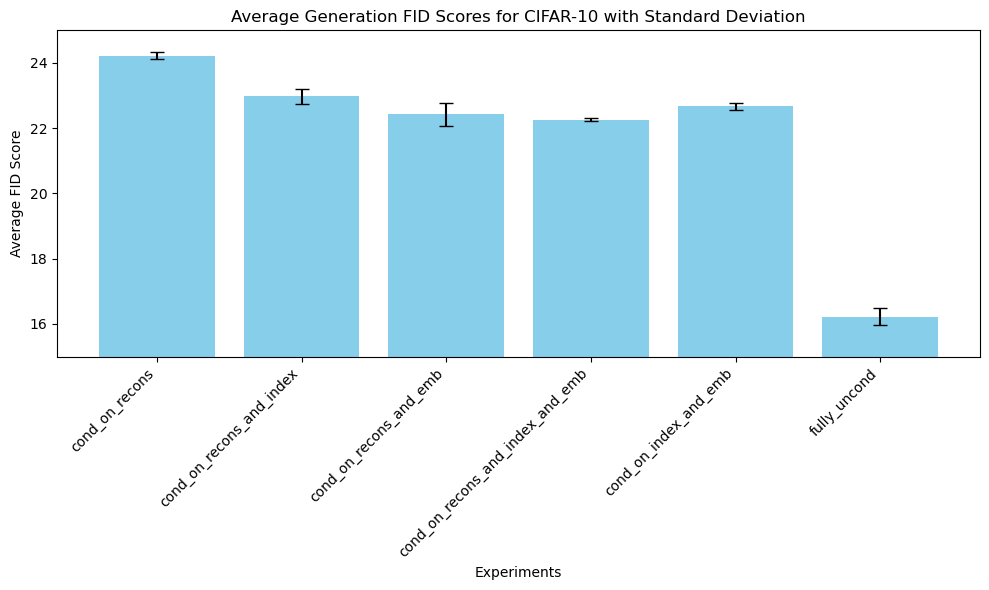

In [26]:
# Create bar plot with error bars
plt.figure(figsize=(10, 6))
plt.bar(experiment_list, cifar10_test_FID_generations_ddpm_avg, yerr=cifar10_test_FID_generations_ddpm_std, capsize=5, color='skyblue')
plt.xlabel('Experiments')
plt.ylabel('Average FID Score')
plt.title('Average Generation FID Scores for CIFAR-10 with Standard Deviation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(15, 25)

# Show plot
plt.show()



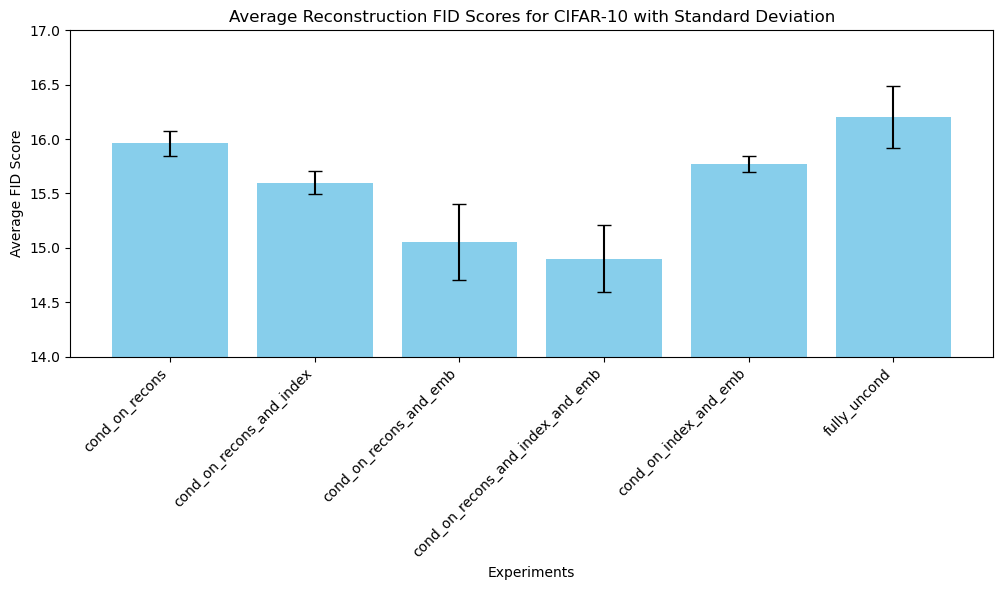

In [11]:
# Create bar plot with error bars
plt.figure(figsize=(10, 6))
plt.bar(experiment_list, cifar10_test_FID_reconstructions_ddpm_avg, yerr=cifar10_test_FID_reconstructions_ddpm_std, capsize=5, color='skyblue')
plt.xlabel('Experiments')
plt.ylabel('Average FID Score')
plt.title('Average Reconstruction FID Scores for CIFAR-10 with Standard Deviation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(14, 17)

# Show plot
plt.show()

---

# Reconstructions Loss

In [12]:
def load_images_from_path_ordered(path):
    # Extract batch and index from the filename and sort based on these
    def get_sort_key(filename):
        parts = filename.split('_')
        batch_index = int(parts[3])
        index_within_batch = int(parts[4].split('.')[0])
        return (batch_index, index_within_batch)
    
    # Get and sort the list of filenames using the custom sort key
    file_list = sorted([filename for filename in os.listdir(path) if filename.endswith(".png")], key=get_sort_key)
    
    images = []
    with ThreadPoolExecutor() as executor:
        futures = {executor.submit(load_image, os.path.join(path, filename)): filename for filename in file_list}
        for future in futures:
            images.append(future.result())
            
    return np.array(images)

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

In [14]:
ddpm_reconstructions_path = '../results_latent_emb/' + dataset + 'cond_on_recons/' + 'seed_1/ddpm/recons/'
ddpm_reconstructions = load_images_from_path_ordered(ddpm_reconstructions_path)

In [15]:
ddpm_reconstructions[0].shape

(32, 32, 3)

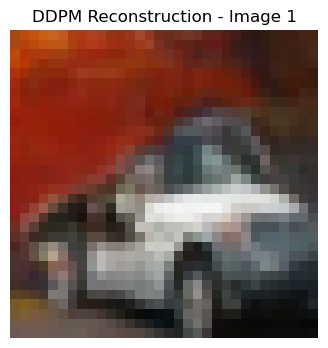

In [16]:
# Plot the second image (index 1) in ddpm_reconstructions
plt.figure(figsize=(4, 4))
plt.imshow(ddpm_reconstructions[6])
plt.axis('off')  # Hide the axes
plt.title('DDPM Reconstruction - Image 1')  # Optional: Add a title to the image
plt.show()

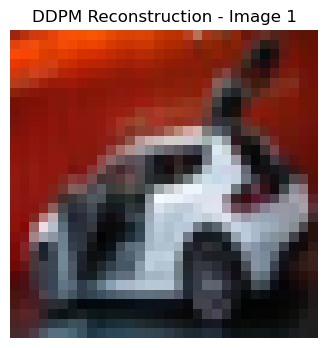

In [17]:
# Plot the second image (index 1) in ddpm_reconstructions
plt.figure(figsize=(4, 4))
plt.imshow(testset.dataset.data[6])
plt.axis('off')  # Hide the axes
plt.title('DDPM Reconstruction - Image 1')  # Optional: Add a title to the image
plt.show()

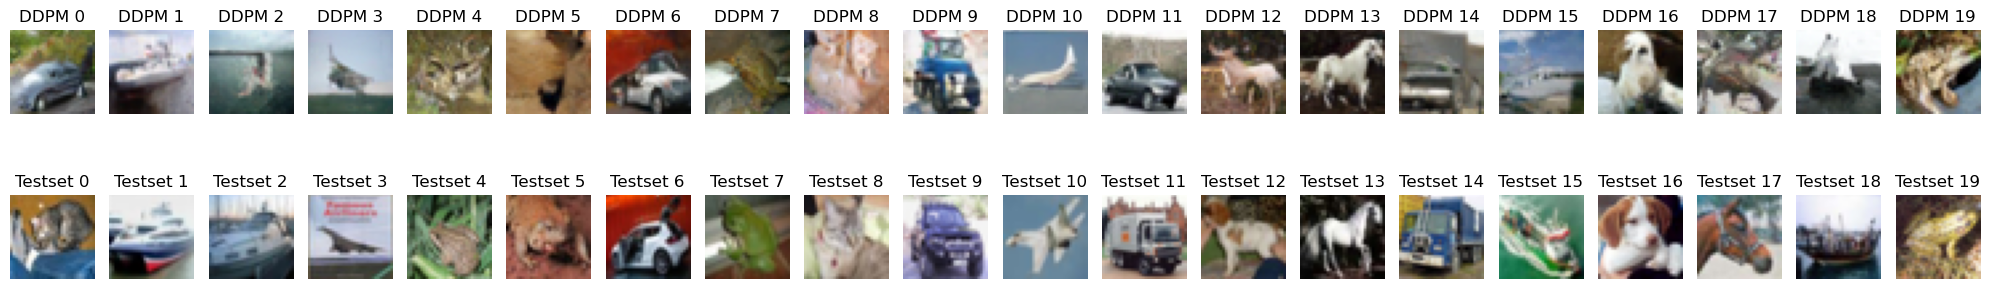

In [18]:
# Plot the images in a 2-row layout
fig, axes = plt.subplots(2, 20, figsize=(20, 4))

for i in range(20):
    # First row: Image from ddpm_reconstructions
    axes[0, i].imshow(ddpm_reconstructions[i])
    axes[0, i].axis('off')
    axes[0, i].set_title(f'DDPM {i}')
    
    # Second row: Image from testset
    axes[1, i].imshow(testset.dataset.data[i])
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Testset {i}')

plt.tight_layout()
plt.show()

In [19]:
def compute_reconstruction_losses(ddpm_reconstructions, testset_images):
    """
    Compute the reconstruction loss (MSE) between all images in ddpm_reconstructions and testset_images.
    
    Parameters:
    ddpm_reconstructions (np.array): The array of reconstructed images.
    testset_images (np.array): The array of ground truth images.
    
    Returns:
    list: The computed reconstruction losses for each image pair.
    float: The mean reconstruction loss.
    """
    # Convert numpy arrays to PyTorch tensors and move to the same device
    ddpm_reconstructions_tensor = torch.tensor(ddpm_reconstructions).permute(0, 3, 1, 2).float()  # Convert to NCHW format
    testset_images_tensor = torch.tensor(testset_images).permute(0, 3, 1, 2).float()  # Convert to NCHW format

    # Define the MSE loss function
    mse_loss = torch.nn.MSELoss()

    # Compute reconstruction loss for all images
    reconstruction_losses = []
    for i in range(ddpm_reconstructions_tensor.size(0)):
        loss = mse_loss(ddpm_reconstructions_tensor[i], testset_images_tensor[i])
        reconstruction_losses.append(loss.item())

    # Mean reconstruction loss
    mean_loss = np.mean(reconstruction_losses)

    return reconstruction_losses, mean_loss

In [20]:
reconstruction_losses, mean_loss = compute_reconstruction_losses(ddpm_reconstructions, testset.dataset.data)

print(f'Mean Reconstruction Loss: {mean_loss}')

Mean Reconstruction Loss: 1806.55630388031


For all experiments: 

In [21]:
# paths to the generated images
base_path = '../results_latent_emb/'
experiment_list = ["cond_on_recons", "cond_on_recons_and_index", "cond_on_recons_and_emb", "cond_on_recons_and_index_and_emb", "cond_on_index_and_emb", "fully_uncond"]
seed_list = ["seed_1", "seed_2", "seed_3"]

# lists to store FID scores for each seed
cifar10_test_reconstruction_loss = np.zeros((len(experiment_list), len(seed_list)))

for j, exp_path in enumerate(experiment_list):
    for i, seed in enumerate(seed_list):
        ddpm_reconstructions_path = base_path + dataset + exp_path + "/" + seed + '/ddpm/recons/'
    
        # load all images from the path and create a numpy array
        ddpm_reconstructions = load_images_from_path_ordered(ddpm_reconstructions_path)
    
        # DDPM reconstruction losses
        _, mean_loss = compute_reconstruction_losses(ddpm_reconstructions, testset.dataset.data)
        cifar10_test_reconstruction_loss[j, i] = mean_loss
        print(str(j*len(seed_list)+i+1), "/", str(len(experiment_list)*len(seed_list)))

1 / 18
2 / 18
3 / 18
4 / 18
5 / 18
6 / 18
7 / 18
8 / 18
9 / 18
10 / 18
11 / 18
12 / 18
13 / 18
14 / 18
15 / 18
16 / 18
17 / 18
18 / 18


In [22]:
cifar10_test_reconstruction_loss

array([[1806.55630388, 1822.17848284, 1818.90176441],
       [1808.71623546, 1805.64121921, 1803.22122309],
       [1804.53842182, 1798.83684312, 1804.38470716],
       [1802.86157319, 1790.47967706, 1799.81334373],
       [1906.93015968, 1893.73683693, 1909.54932878],
       [8009.23752862, 7965.27304188, 7906.90859298]])

In [23]:
# Compute row averages
cifar10_test_reconstruction_loss_avg = np.mean(cifar10_test_reconstruction_loss, axis=1)
cifar10_test_reconstruction_loss_std = np.std(cifar10_test_reconstruction_loss, axis=1)

# The resulting matrices and averages
print("cifar10_test_FID_generations_ddpm_avg: \n", cifar10_test_reconstruction_loss_avg)
print("cifar10_test_FID_reconstructions_ddpm_avg: \n", cifar10_test_reconstruction_loss_std)

cifar10_test_FID_generations_ddpm_avg: 
 [1815.87885038 1805.85955925 1802.58665736 1797.71819799 1903.4054418
 7960.47305449]
cifar10_test_FID_reconstructions_ddpm_avg: 
 [ 6.72639705  2.24863581  2.65226158  5.26751457  6.91984835 41.91326502]


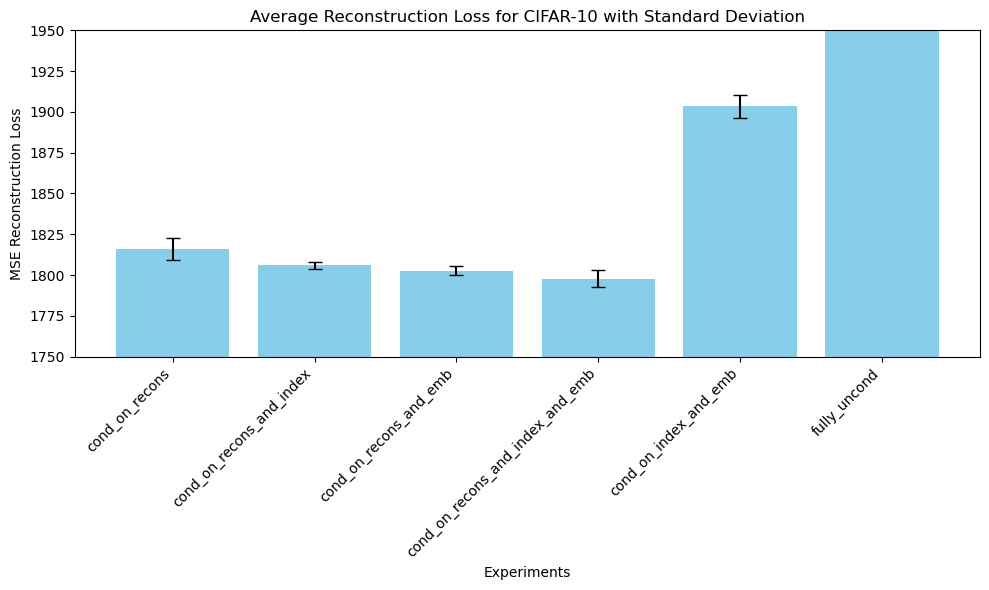

In [29]:
# Create bar plot with error bars
plt.figure(figsize=(10, 6))
plt.bar(experiment_list, cifar10_test_reconstruction_loss_avg, yerr=cifar10_test_reconstruction_loss_std, capsize=5, color='skyblue')
plt.xlabel('Experiments')
plt.ylabel('MSE Reconstruction Loss')
plt.title('Average Reconstruction Loss for CIFAR-10 with Standard Deviation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(1750, 1950)

# Show plot
plt.show()

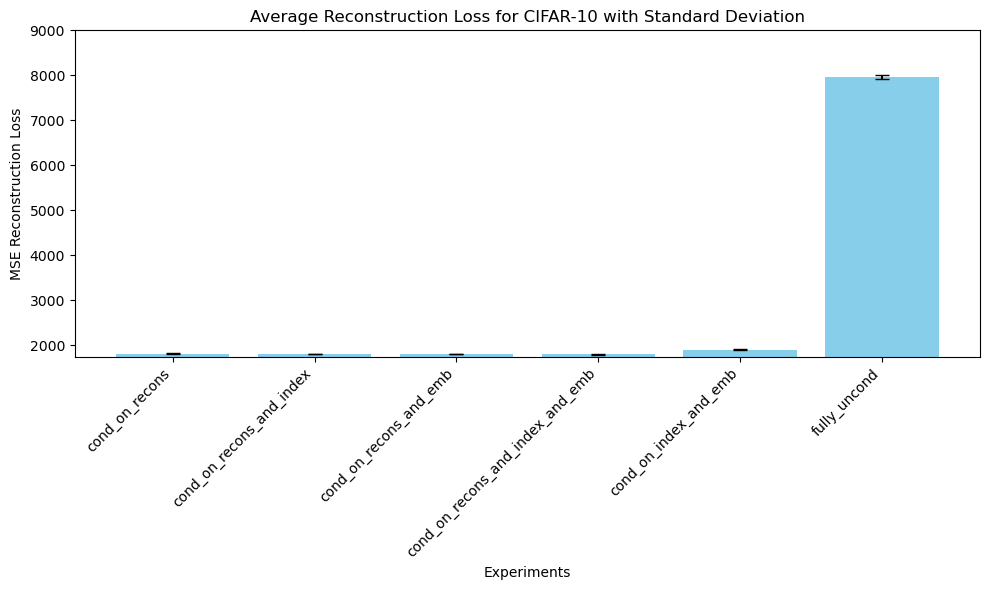

In [31]:
# Create bar plot with error bars
plt.figure(figsize=(10, 6))
plt.bar(experiment_list, cifar10_test_reconstruction_loss_avg, yerr=cifar10_test_reconstruction_loss_std, capsize=5, color='skyblue')
plt.xlabel('Experiments')
plt.ylabel('MSE Reconstruction Loss')
plt.title('Average Reconstruction Loss for CIFAR-10 with Standard Deviation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylim(1750, 9000)

# Show plot
plt.show()